# **Cybersecurity Network Traffic Dataset: Baseline**

This dataset contains **network traffic records used for cybersecurity analysis**, specifically focused on detecting **Distributed Denial of Service (DDoS) and network flooding attacks**.  
Each CSV file represents traffic captured during a **specific attack type or normal network behavior**.


The dataset is divided into multiple CSV files, each corresponding to a specific attack category or normal traffic type.

| File | Description |
|-----|-------------|
| `DrDoS_DNS.csv` | DNS amplification Distributed Reflection Denial of Service attack traffic |
| `DrDoS_LDAP.csv` | LDAP reflection DDoS attack traffic |
| `DrDoS_MSSQL.csv` | MSSQL reflection DDoS attack traffic |
| `DrDoS_NetBIOS.csv` | NetBIOS reflection DDoS attack traffic |
| `DrDoS_NTP.csv` | NTP amplification attack traffic |
| `DrDoS_SNMP.csv` | SNMP reflection DDoS attack traffic |
| `DrDoS_SSDP.csv` | SSDP reflection DDoS attack traffic |
| `DrDoS_UDP.csv` | UDP flood distributed denial of service traffic |
| `Syn.csv` | SYN flood attack traffic |

These attack types are examples of volumetric or reflection-based DDoS attacks, where attackers overwhelm a server or network by generating massive traffic.

For training, we only consider the following CSV files due to limited computational resources. These CSV files were selected because these traffic types are commonly associated with reflection and amplification attacks. In these attacks, the attacker sends spoofed requests to legitimate servers (such as DNS, LDAP, or NTP services). The source IP address is forged to appear as the victim's address. As a result, the legitimate server sends the response to the victim instead of the attacker. Therefore, the analysis will focus on the following datasets:

- **DNS.csv**
- **LDAP.csv**
- **NTP.csv**
- **Syn.csv**



### **00 Libraries**

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import seaborn as sns

### **01 Load Dataset**

In [6]:
train_path = "preprocessed_data/train.csv"
val_path =  "preprocessed_data/val.csv"
test_path =  "preprocessed_data/test.csv"

In [7]:
train = pd.read_csv(train_path)
val = pd.read_csv(val_path)
test = pd.read_csv(test_path)

In [8]:
# Train
X_train = train.drop("Label", axis=1)
y_train = train["Label"]

# Validation
X_val = val.drop("Label", axis=1)
y_val = val["Label"]

# Test
X_test = test.drop("Label", axis=1)
y_test = test["Label"]

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# **1. Baseline**

In [61]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

def create_baseline_model(input_dim):

    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        layers.Dense(32, activation="relu"),
        layers.Dense(16, activation="relu"),

        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.AUC(name="auc")
        ]
    )

    return model

In [62]:
model = create_baseline_model(X_train.shape[1])
model.summary()

Model: "sequential_35"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_104 (Dense)           (None, 32)                2048      
                                                                 
 dense_105 (Dense)           (None, 16)                528       
                                                                 
 dense_106 (Dense)           (None, 1)                 17        
                                                                 
Total params: 2593 (10.13 KB)
Trainable params: 2593 (10.13 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [63]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=256,
    verbose=1
)

Epoch 1/20
98/98 [==============================] - 1s 4ms/step - loss: 0.1924 - accuracy: 0.9633 - auc: 0.9924 - val_loss: 0.0433 - val_accuracy: 0.9928 - val_auc: 0.9990
Epoch 2/20
98/98 [==============================] - 0s 2ms/step - loss: 0.0238 - accuracy: 0.9963 - auc: 0.9995 - val_loss: 0.0169 - val_accuracy: 0.9968 - val_auc: 0.9995
Epoch 3/20
98/98 [==============================] - 0s 2ms/step - loss: 0.0115 - accuracy: 0.9978 - auc: 0.9996 - val_loss: 0.0120 - val_accuracy: 0.9976 - val_auc: 0.9996
Epoch 4/20
98/98 [==============================] - 0s 2ms/step - loss: 0.0084 - accuracy: 0.9981 - auc: 0.9997 - val_loss: 0.0102 - val_accuracy: 0.9978 - val_auc: 0.9996
Epoch 5/20
98/98 [==============================] - 0s 2ms/step - loss: 0.0072 - accuracy: 0.9984 - auc: 0.9997 - val_loss: 0.0093 - val_accuracy: 0.9982 - val_auc: 0.9996
Epoch 6/20
98/98 [==============================] - 0s 2ms/step - loss: 0.0065 - accuracy: 0.9987 - auc: 0.9997 - val_loss: 0.0083 - val_acc

In [71]:
y_pred_probs = model.predict(
    X_test,
    batch_size=4096,
    verbose=1
)

MemoryError: Unable to allocate 464. MiB for an array with shape (1928897, 63) and data type float32

In [18]:
y_pred = (y_pred_probs > 0.5).astype(int)

In [21]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("AUC:", tf.keras.metrics.AUC()(y_test, y_pred_probs).numpy() )

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9995525940472716
Precision: 0.9999968817091975
Recall: 0.9995548010319057
F1 Score: 0.9997757925007658
AUC: 0.99973935

Confusion Matrix:
[[   3909       6]
 [    857 1924125]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      1.00      0.90      3915
           1       1.00      1.00      1.00   1924982

    accuracy                           1.00   1928897
   macro avg       0.91      1.00      0.95   1928897
weighted avg       1.00      1.00      1.00   1928897



In [25]:
def confusion_matrix_heatmap(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap="pink",
            xticklabels=["No Survive", "Survive"],
            yticklabels=["No Survive", "Survive"])

    plt.title("Confusion Matrix", fontsize=14)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

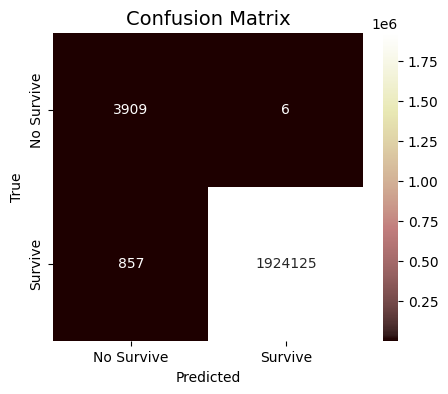

In [26]:
confusion_matrix_heatmap(y_test, y_pred)

# **2. Optuna**

In [35]:
import sys
!{sys.executable} -m pip install plotly

In [28]:
import sys
!{sys.executable} -m pip install optuna

  Using cached colorlog-6.10.1-py3-none-any.whl.metadata (11 kB)
  Using cached pyyaml-6.0.3-cp310-cp310-win_amd64.whl.metadata (2.4 kB)
  Using cached mako-1.3.10-py3-none-any.whl.metadata (2.9 kB)
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ----------------------------- ---------- 1.6/2.1 MB 7.6 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 8.0 MB/s  0:00:00
Using cached colorlog-6.10.1-py3-none-any.whl (11 kB)
Using cached mako-1.3.10-py3-none-any.whl (78 kB)
Using cached pyyaml-6.0.3-cp310-cp310-win_amd64.whl (158 kB)

   ----- ---------------------------------- 1/8 [PyYAML]
   ----- ---------------------------------- 1/8 [PyYAML]
   ----- ---------------------------------- 1/8 [PyYAML]
   ---------- ----------------------------- 2/8 [Mako]
   ---------- ----------------------------- 2/8 [Mako]
   ---------- ----------------------------- 2/8 [Mako]
   ---------- ----------------------------- 2/8 [Mako]
   ---------- ------------

In [40]:
import time
import numpy as np
import optuna
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


In [42]:
RANDOM_STATE = 42
N_TRIALS = 100
N_RUNS_TIMING = 10

HIDDEN_SIZE_MIN = 32
HIDDEN_SIZE_MAX = 256

LR_MIN = 1e-5
LR_MAX = 1e-2

BATCH_SIZES = [32, 64, 128]

DIRECTIONS = ["maximize", "minimize"]

In [43]:
def build_model(hidden_size, lr):

    model = keras.Sequential([
        layers.Dense(hidden_size, activation="relu", input_shape=(X_train.shape[1],)),
        layers.Dense(hidden_size // 2, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])

    optimizer = keras.optimizers.Adam(learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [44]:
def train_and_evaluate(model, batch_size):

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=10,
        batch_size=batch_size,
        verbose=0
    )

    # predictions
    y_pred = model.predict(X_val, verbose=0)
    y_pred = (y_pred > 0.5).astype(int)

    f1 = f1_score(y_val, y_pred)

    val_loss = history.history["val_loss"][-1]

    return val_loss, f1

In [45]:
def measure_inference_time(model, X_val, n_runs=N_RUNS_TIMING):

    times = []

    for _ in range(n_runs):

        start = time.perf_counter()

        model.predict(X_val, verbose=0)

        end = time.perf_counter()

        times.append(end - start)

    return float(np.mean(times))

In [46]:
def objective(trial):

    hidden_size = trial.suggest_int("hidden_size", HIDDEN_SIZE_MIN, HIDDEN_SIZE_MAX)

    lr = trial.suggest_float("lr", LR_MIN, LR_MAX, log=True)

    batch_size = trial.suggest_categorical("batch_size", BATCH_SIZES)

    model = build_model(hidden_size, lr)

    val_loss, f1 = train_and_evaluate(model, batch_size)

    inference_time = measure_inference_time(model, X_val)

    return f1, inference_time

In [47]:
def create_study():

    study = optuna.create_study(
        directions=DIRECTIONS,
        sampler=optuna.samplers.NSGAIISampler(seed=RANDOM_STATE)
    )

    return study

In [ ]:
def print_pareto_front(study):
    pareto_trials = study.best_trials

    print(f"Pareto-front trials: {len(pareto_trials)}")
    print("-"*40)

    for t in pareto_trials:

        f1_score_val = t.values[0]

        inf_time_ms = t.values[1] * 1000

        print(f"Trial #{t.number} | F1: {f1_score_val:.4f} | Inference: {inf_time_ms:.3f} ms")
        print("Params:", t.params)
        print()

def plot_pareto_front(study):

    pareto_trials = study.best_trials

    f1_scores = [t.values[0] for t in pareto_trials]
    inference_times = [t.values[1]*1000 for t in pareto_trials]

    plt.figure()

    plt.scatter(inference_times, f1_scores)

    for i, t in enumerate(pareto_trials):

        plt.annotate(str(t.number), (inference_times[i], f1_scores[i]))

    plt.xlabel("Inference Time (ms)")
    plt.ylabel("F1 Score")
    plt.title("Pareto Front")

    plt.grid()

    plt.show()

In [50]:
study = create_study()

[I 2026-03-26 13:26:21,014] A new study created in memory with name: no-name-3b7eb910-6a42-43d9-851a-4dd742e221ff


In [52]:
study.optimize(objective, n_trials=30)

[I 2026-03-26 13:27:18,778] Trial 2 finished with values: [0.9961550785004806, 0.4828855199999452] and parameters: {'hidden_size': 36, 'lr': 0.008123245085588688, 'batch_size': 32}.
[I 2026-03-26 13:27:40,468] Trial 3 finished with values: [0.9979256422530717, 0.6298297399998773] and parameters: {'hidden_size': 73, 'lr': 8.17949947521167e-05, 'batch_size': 32}.
[I 2026-03-26 13:27:52,132] Trial 4 finished with values: [0.9953725865645444, 0.2186885200006145] and parameters: {'hidden_size': 169, 'lr': 2.621087878265438e-05, 'batch_size': 128}.
[I 2026-03-26 13:28:01,501] Trial 5 finished with values: [0.9972882437390334, 0.26616937999970103] and parameters: {'hidden_size': 208, 'lr': 3.972110727381908e-05, 'batch_size': 64}.
[I 2026-03-26 13:28:08,344] Trial 6 finished with values: [0.9972882437390334, 0.26290752999993855] and parameters: {'hidden_size': 168, 'lr': 3.247673570627447e-05, 'batch_size': 128}.
[I 2026-03-26 13:28:17,799] Trial 7 finished with values: [0.998084902649218, 0.

In [53]:
print_pareto_front(study)

Pareto-front trials: 8
----------------------------------------
Trial #4 | F1: 0.9954 | Inference: 218.689 ms
Params: {'hidden_size': 169, 'lr': 2.621087878265438e-05, 'batch_size': 128}

Trial #8 | F1: 0.9984 | Inference: 259.497 ms
Params: {'hidden_size': 59, 'lr': 0.0003058656666978527, 'batch_size': 64}

Trial #10 | F1: 0.9987 | Inference: 264.659 ms
Params: {'hidden_size': 250, 'lr': 0.002115429079726122, 'batch_size': 32}

Trial #12 | F1: 0.9982 | Inference: 232.529 ms
Params: {'hidden_size': 119, 'lr': 6.516990611177177e-05, 'batch_size': 32}

Trial #19 | F1: 0.9989 | Inference: 278.733 ms
Params: {'hidden_size': 143, 'lr': 0.0003699972431463808, 'batch_size': 32}

Trial #23 | F1: 0.9990 | Inference: 607.804 ms
Params: {'hidden_size': 228, 'lr': 0.0025764174425233167, 'batch_size': 64}

Trial #30 | F1: 0.9974 | Inference: 219.794 ms
Params: {'hidden_size': 236, 'lr': 5.232216089948759e-05, 'batch_size': 128}

Trial #31 | F1: 0.9987 | Inference: 274.052 ms
Params: {'hidden_size':

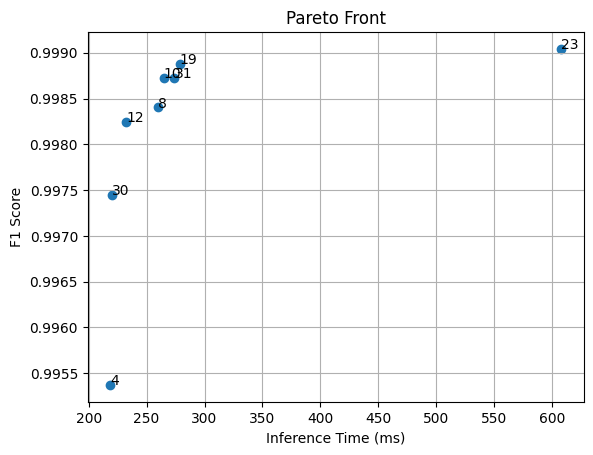

In [60]:
plot_pareto_front(study)

In [54]:
best_f1_trial = max(study.best_trials, key=lambda t: t.values[0])

print(best_f1_trial.params)

{'hidden_size': 228, 'lr': 0.0025764174425233167, 'batch_size': 64}


# **4.Train Best Model**

In [56]:
best_params = best_f1_trial.params

final_model = build_model(
    best_params["hidden_size"],
    best_params["lr"]
)

final_model.fit(
    X_train,
    y_train,
    batch_size=best_params["batch_size"],
    epochs=20,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/20
392/392 [==============================] - 1s 2ms/step - loss: 0.0292 - accuracy: 0.9959 - val_loss: 0.0185 - val_accuracy: 0.9971
Epoch 2/20
392/392 [==============================] - 1s 2ms/step - loss: 0.0070 - accuracy: 0.9981 - val_loss: 0.0062 - val_accuracy: 0.9986
Epoch 3/20
392/392 [==============================] - 1s 2ms/step - loss: 0.0039 - accuracy: 0.9986 - val_loss: 0.0060 - val_accuracy: 0.9984
Epoch 4/20
392/392 [==============================] - 1s 2ms/step - loss: 0.0031 - accuracy: 0.9989 - val_loss: 0.0068 - val_accuracy: 0.9981
Epoch 5/20
392/392 [==============================] - 1s 2ms/step - loss: 0.0057 - accuracy: 0.9987 - val_loss: 0.0071 - val_accuracy: 0.9987
Epoch 6/20
392/392 [==============================] - 1s 2ms/step - loss: 0.0032 - accuracy: 0.9990 - val_loss: 0.0070 - val_accuracy: 0.9986
Epoch 7/20
392/392 [==============================] - 1s 2ms/step - loss: 0.0028 - accuracy: 0.9992 - val_loss: 0.0056 - val_accuracy: 0.9987
Epoch 

In [57]:
y_pred = final_model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

test_f1 = f1_score(y_test, y_pred)

print("Test F1 Score:", test_f1)

60279/60279 [==============================] - 131s 2ms/step
Test F1 Score: 0.9997591614140733


In [58]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("AUC:", tf.keras.metrics.AUC()(y_test, y_pred_probs).numpy() )

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9995194144632917
Precision: 0.9999963618768349
Recall: 0.9995220734531544
F1 Score: 0.9997591614140733
AUC: 0.99973935

Confusion Matrix:
[[   3908       7]
 [    920 1924062]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      1.00      0.89      3915
           1       1.00      1.00      1.00   1924982

    accuracy                           1.00   1928897
   macro avg       0.90      1.00      0.95   1928897
weighted avg       1.00      1.00      1.00   1928897



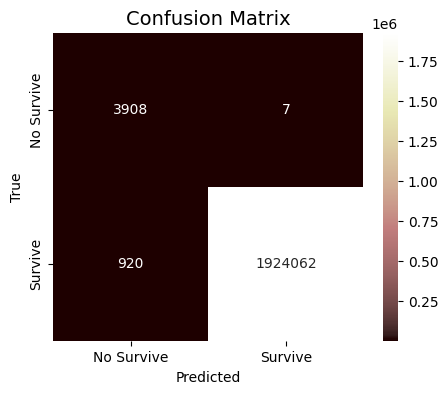

In [59]:
confusion_matrix_heatmap(y_test, y_pred)